In [1]:
import gc
import torch
import faiss 
import random
import numpy as np
from scipy.io import mmread
import torch.nn.functional as F
from torch.nn import TripletMarginLoss
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv
import torch.optim as optim
# from sklearn.cluster import KMeans
# import torch_geometric.utils as pyg_utils
import matplotlib.pyplot as plt
# from sklearn.decomposition import PCA
# import pandas as pd
# import seaborn as sns

In [2]:
#check cuda 
if torch.cuda.is_available():
    print(f"CUDA Device Count: {torch.cuda.device_count()}")
    print(f"Device Name: {torch.cuda.get_device_name(0)}")
    print(f"Compute Capability: {torch.cuda.get_device_capability(0)}")
    print(f"Memory Allocated: {torch.cuda.memory_allocated(0) / 1e9} GB")
    print(f"Memory Cached: {torch.cuda.memory_reserved(0) / 1e9} GB")
else:
    print("No CUDA-compatible GPU found.")

torch.cuda.empty_cache()

CUDA Device Count: 1
Device Name: NVIDIA GeForce RTX 2060
Compute Capability: (7, 5)
Memory Allocated: 0.0 GB
Memory Cached: 0.0 GB


In [6]:
rawData = mmread('../scRNA.mtx')
coo_matrix = rawData.tocoo()
print(coo_matrix)
print(coo_matrix.shape)

<COOrdinate sparse matrix of dtype 'float64'
	with 86422438 stored elements and shape (34619, 27180)>
  Coords	Values
  (30, 0)	878.85046
  (44, 0)	2636.5513
  (58, 0)	878.85046
  (74, 0)	878.85046
  (77, 0)	878.85046
  (109, 0)	878.85046
  (225, 0)	3515.4019
  (247, 0)	878.85046
  (272, 0)	878.85046
  (273, 0)	1318.2756
  (365, 0)	878.85046
  (366, 0)	2636.5513
  (421, 0)	878.85046
  (431, 0)	1757.7009
  (440, 0)	878.85046
  (442, 0)	5273.1025
  (499, 0)	16698.158
  (594, 0)	878.85046
  (649, 0)	1757.7009
  (688, 0)	878.85046
  (706, 0)	878.85046
  (831, 0)	1757.7009
  (835, 0)	2636.5513
  (867, 0)	878.85046
  (911, 0)	2636.5513
  :	:
  (32162, 27179)	142.14685
  (32202, 27179)	88.841736
  (32298, 27179)	177.68347
  (32423, 27179)	59.227825
  (32425, 27179)	177.68347
  (32564, 27179)	88.841736
  (33015, 27179)	177.68347
  (33454, 27179)	177.68347
  (33504, 27179)	177.68347
  (33538, 27179)	177.68347
  (33578, 27179)	88.841736
  (33636, 27179)	177.68347
  (33647, 27179)	284.01257
  (33

##### Process And Modify Data

In [7]:
def clean_and_split_data(coo_matrix, max_number):
    #get only non-zero values
    total_nnz = coo_matrix.nnz 

    # Ensure max_nnz doesn’t exceed total
    if max_number >= total_nnz:
        raise ValueError(f"max_nnz ({max_number}) must be less than total non-zero elements ({total_nnz})")
    
    rows = coo_matrix.row
    cols = coo_matrix.col
    data = coo_matrix.data
    
    selected_indices = np.arange(max_number)  

    selected = coo_matrix.__class__(
        (data[selected_indices], (rows[selected_indices], cols[selected_indices])),
        shape=coo_matrix.shape
    )
    
    return selected

processed_data = clean_and_split_data(coo_matrix=coo_matrix, max_number=900000)
print(processed_data)

<COOrdinate sparse matrix of dtype 'float64'
	with 900000 stored elements and shape (34619, 27180)>
  Coords	Values
  (30, 0)	878.85046
  (44, 0)	2636.5513
  (58, 0)	878.85046
  (74, 0)	878.85046
  (77, 0)	878.85046
  (109, 0)	878.85046
  (225, 0)	3515.4019
  (247, 0)	878.85046
  (272, 0)	878.85046
  (273, 0)	1318.2756
  (365, 0)	878.85046
  (366, 0)	2636.5513
  (421, 0)	878.85046
  (431, 0)	1757.7009
  (440, 0)	878.85046
  (442, 0)	5273.1025
  (499, 0)	16698.158
  (594, 0)	878.85046
  (649, 0)	1757.7009
  (688, 0)	878.85046
  (706, 0)	878.85046
  (831, 0)	1757.7009
  (835, 0)	2636.5513
  (867, 0)	878.85046
  (911, 0)	2636.5513
  :	:
  (14359, 264)	241.19199
  (14367, 264)	96.47679
  (14368, 264)	24.119198
  (14369, 264)	24.119198
  (14374, 264)	48.238396
  (14376, 264)	120.59599
  (14379, 264)	96.47679
  (14382, 264)	24.119198
  (14383, 264)	48.238396
  (14402, 264)	24.119198
  (14403, 264)	24.119198
  (14410, 264)	120.59599
  (14412, 264)	48.238396
  (14414, 264)	48.238396
  (14417, 

##### Graph Data Object

In [8]:
def cell_graph(data, threshold):

    gene_expression = data.data
    
    x = np.asarray(gene_expression, dtype=np.float32)
    x = x.reshape(-1, 1)


    gpu_resource_manager = faiss.StandardGpuResources() 
    similarity_object = faiss.IndexFlatL2(1)
    similarity_object_in_gpu = faiss.index_cpu_to_gpu(gpu_resource_manager, 0, similarity_object)


    print(similarity_object_in_gpu.is_trained)  
    print(f"FAISS index type: {type(similarity_object_in_gpu)}") 


    similarity_object_in_gpu.add(x)
    k=2
    distances, indices = similarity_object_in_gpu.search(x, k + 1)
    
    edge_index_list = []
    outliers = []
    
    for i in range(len(gene_expression)):
        nearest_neighbors = indices[i, 1:k+1]  
        neighbor_distances = distances[i, 1:k+1]
        
        for j, dist in zip(nearest_neighbors, neighbor_distances):
            if dist <= threshold ** 2:
                edge_index_list.append((i, j))
            else:
                outliers.append(int(j))
    

    edge_index_np = np.array(edge_index_list).T
    edge_index = torch.tensor(edge_index_np, dtype=torch.long) if edge_index_np.size > 0 else torch.empty((2, 0), dtype=torch.long)

    cleaned_outliers = list(set(outliers))
    print(cleaned_outliers)

    x_tensor = torch.tensor(x, dtype=torch.float32)
    pyg_data = Data(edge_index=edge_index, x=x_tensor)
    print(pyg_data)
    return pyg_data

data = cell_graph(data=processed_data,threshold=500)

True
FAISS index type: <class 'faiss.swigfaiss.GpuIndexFlat'>
[397700, 696586, 223116, 163986, 823956, 4763, 490399, 333091, 177955, 747556, 284331, 157360, 283697, 24500, 340662, 703416, 845753, 223163, 372669, 774463, 395840, 538689, 744770, 291661, 217679, 341846, 617691, 507749, 507750, 744808, 877161, 696554, 321899, 75244, 642539, 552686, 659695, 800882]
Data(x=[900000, 1], edge_index=[2, 1799946])


In [9]:
gc.collect()
torch.cuda.empty_cache()

In [10]:
gene_expression_lvl = data.x.cpu().numpy()

k = 10  
d = gene_expression_lvl.shape[1] 
kmeans = faiss.Kmeans(d, k, niter=300, gpu=True)  


kmeans.train(gene_expression_lvl)

_, labels = kmeans.index.search(gene_expression_lvl, 1) 
labels = labels.flatten()

In [11]:
cluster_counts = np.bincount(labels)  


for i in range(k):
    print(f"Cluster {i}: {cluster_counts[i]} nodes")

Cluster 0: 48621 nodes
Cluster 1: 12918 nodes
Cluster 2: 107 nodes
Cluster 3: 449048 nodes
Cluster 4: 244973 nodes
Cluster 5: 9693 nodes
Cluster 6: 30186 nodes
Cluster 7: 5867 nodes
Cluster 8: 1493 nodes
Cluster 9: 97094 nodes


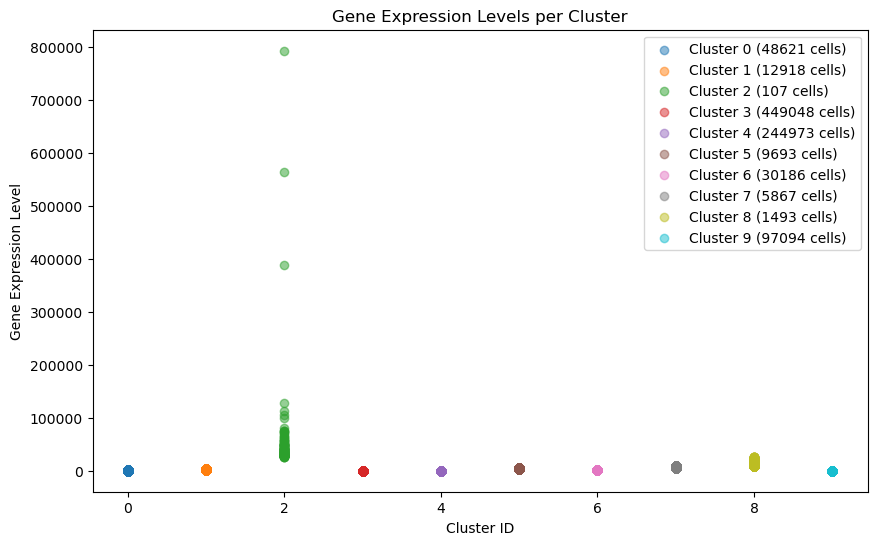

In [12]:
gene_expression_levels = data.x.cpu().numpy().flatten() 

plt.figure(figsize=(10, 6))
unique_labels = np.unique(labels)


for label in unique_labels:
    cluster_cells = gene_expression_lvl[labels == label]
    num_cells = len(cluster_cells)
    plt.scatter(np.full_like(cluster_cells, label), cluster_cells, alpha=0.5, label=f'Cluster {label} ({num_cells} cells)')

# Label the axes
plt.xlabel('Cluster ID')
plt.ylabel('Gene Expression Level')
plt.title('Gene Expression Levels per Cluster')


plt.legend()
plt.show()

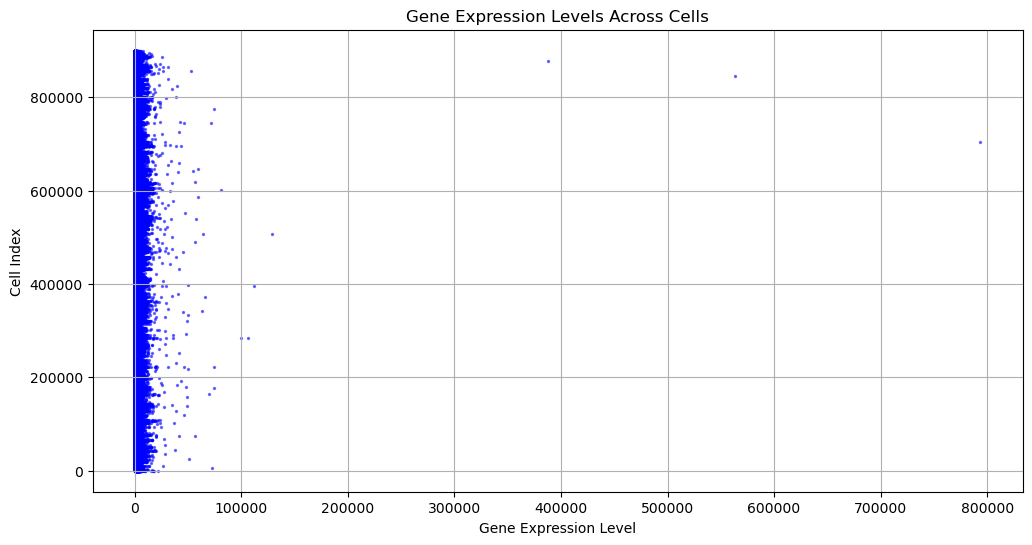

In [ ]:
gene_expression_levels_cpu = gene_expression_levels.cpu().numpy() if hasattr(gene_expression_levels, "cpu") else gene_expression_levels
num_cells = len(gene_expression_levels_cpu)

cell_indices = np.arange(num_cells)

plt.figure(figsize=(12, 6))
plt.scatter(gene_expression_levels_cpu, cell_indices, alpha=0.5, s=2, c='blue')  

plt.xlabel('Gene Expression Level')
plt.ylabel('Cell Index')
plt.title('Gene Expression Levels Across Cells')
plt.grid(True)
plt.show()

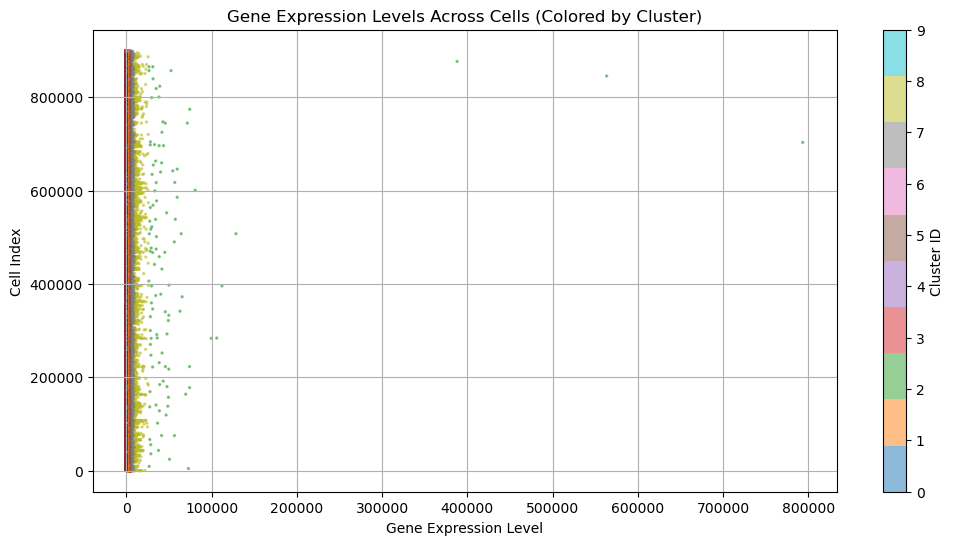

In [14]:
plt.figure(figsize=(12, 6))
plt.scatter(gene_expression_levels_cpu, cell_indices, c=labels, cmap='tab10', alpha=0.5, s=2)
plt.xlabel('Gene Expression Level')
plt.ylabel('Cell Index')
plt.title('Gene Expression Levels Across Cells (Colored by Cluster)')
plt.colorbar(label='Cluster ID')
plt.grid(True)
plt.show()

Graph Neural Network

In [15]:
class GraphSAGE(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers):
        super(GraphSAGE, self).__init__()
        self.convs = torch.nn.ModuleList()
        self.convs.append(SAGEConv(in_channels, hidden_channels))  
        
        for _ in range(num_layers - 2):  
            self.convs.append(SAGEConv(hidden_channels, hidden_channels))
        
        self.convs.append(SAGEConv(hidden_channels, out_channels))  

    def forward(self, x, edge_index):
        for conv in self.convs[:-1]: 
            x = conv(x, edge_index)
            x = F.relu(x)
            x = F.dropout(x, p=0.5, training=self.training)
        x = self.convs[-1](x, edge_index) 
        return x  

Traning Without Loss Function

In [16]:
#train without loss function
device = torch.device('cuda' if torch.cuda.is_available else 'cpu')

model = GraphSAGE(in_channels=1, hidden_channels=128, out_channels=64, num_layers=2).to(device)
data = data.to(device)

model.eval()
with torch.no_grad():
    embeddings = model(data.x, data.edge_index)

print(embeddings.shape)

torch.save(model, 'entire_model.pth')

torch.Size([900000, 64])


In [17]:
embeddings_np = embeddings.cpu().numpy()

d = embeddings_np.shape[1]  
k = 10
kmeans = faiss.Kmeans(d, k, niter=300, gpu=True)  


kmeans.train(embeddings_np)
_, labels = kmeans.index.search(embeddings_np, 1)


labels = torch.tensor(labels.flatten(), device='cuda')
print(labels.shape)

torch.Size([900000])


In [18]:
cluster_counts = torch.bincount(labels)

# Print the number of cells in each cluster
for i, count in enumerate(cluster_counts):
    print(f"Cluster {i}: {count.item()} cells")

Cluster 0: 1251 cells
Cluster 1: 8764 cells
Cluster 2: 84 cells
Cluster 3: 4103 cells
Cluster 4: 715103 cells
Cluster 5: 7463 cells
Cluster 6: 32028 cells
Cluster 7: 6423 cells
Cluster 8: 3785 cells
Cluster 9: 120996 cells


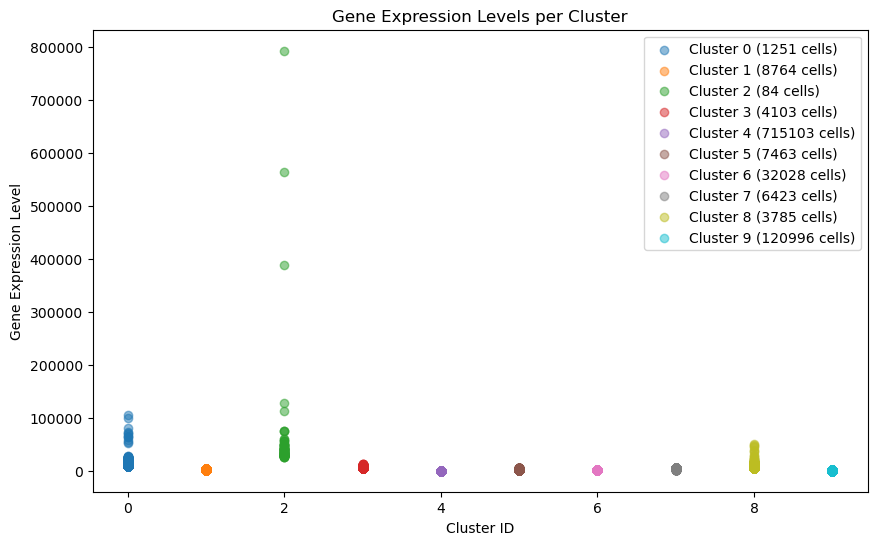

In [19]:
labels_cpu = labels.cpu().numpy()
gene_expression_levels_cpu = gene_expression_levels


plt.figure(figsize=(10, 6))
unique_labels = np.unique(labels_cpu)

for label in unique_labels:
    cluster_cells = gene_expression_levels_cpu[labels_cpu == label]
    num_cells = len(cluster_cells)
    plt.scatter(np.full_like(cluster_cells, label), cluster_cells, alpha=0.5, label=f'Cluster {label} ({num_cells} cells)')


plt.xlabel('Cluster ID')
plt.ylabel('Gene Expression Level')
plt.title('Gene Expression Levels per Cluster')
plt.legend()
plt.show()

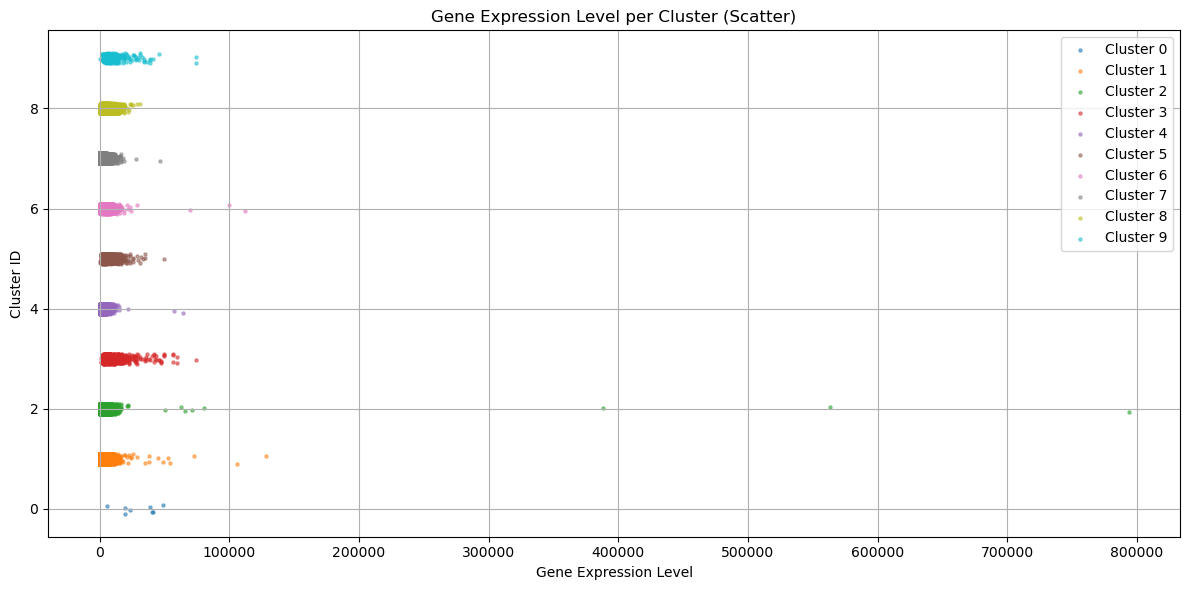

In [39]:
plt.figure(figsize=(12, 6))

for label in np.unique(labels_cpu):
    # Get gene expression values for cells in this cluster
    cluster_cells = gene_expression_levels_cpu[labels_cpu == label]
    
    # Generate random jitter for better visual separation
    y = np.full_like(cluster_cells, label) + np.random.uniform(-0.1, 0.1, size=cluster_cells.shape)

    plt.scatter(cluster_cells, y, alpha=0.5, s=5, label=f'Cluster {label}')

plt.xlabel('Gene Expression Level')
plt.ylabel('Cluster ID')
plt.title('Gene Expression Level per Cluster (Scatter)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [41]:
gc.collect()
torch.cuda.empty_cache()

In [42]:
print(f"Allocated: {torch.cuda.memory_allocated() / 1024**2:.2f} MB")
print(f"Reserved : {torch.cuda.memory_reserved() / 1024**2:.2f} MB")
print(f"Max Allocated: {torch.cuda.max_memory_allocated() / 1024**2:.2f} MB")
print(f"Max Reserved : {torch.cuda.max_memory_reserved() / 1024**2:.2f} MB")


Allocated: 1491.07 MB
Reserved : 2526.00 MB
Max Allocated: 2389.06 MB
Max Reserved : 2914.00 MB


Model 1  + Testing with parameter changes - No Loss Function

In [43]:
model1 = GraphSAGE(in_channels=1, hidden_channels=64,out_channels=64, num_layers=4).to(device)
model1_1 = GraphSAGE(in_channels=1, hidden_channels=64,out_channels=64, num_layers=8).to(device)
model1_2 = GraphSAGE(in_channels=1, hidden_channels=64,out_channels=64, num_layers=16).to(device)


model1.eval()
with torch.no_grad():
    embeddings_model1 = model1(data.x, data.edge_index)

print(embeddings_model1.shape)

model1.eval()
with torch.no_grad():
    embeddings_model1_1 = model1_1(data.x, data.edge_index)

print(embeddings_model1_1.shape)


model1.eval()
with torch.no_grad():
    embeddings_model1_2 = model1_2(data.x, data.edge_index)

print(embeddings_model1_2.shape)


torch.save(model1, 'entire_model1.pth')
torch.save(model1_1, 'entire_model1_1.pth')
torch.save(model1_2, 'entire_model1_2.pth')

torch.Size([900000, 64])
torch.Size([900000, 64])
torch.Size([900000, 64])


In [44]:
gc.collect()
torch.cuda.empty_cache()

Model 2 with +loss function - Triplet Loss

In [45]:
def generate_triplets_with_faiss_gpu(embeddings, k=5, num_triplets_per_node=1):
    device = embeddings.device
    emb_np = embeddings.detach().cpu().numpy().astype('float32')
    num_nodes, emb_dim = emb_np.shape

    index = faiss.IndexFlatL2(emb_dim)
    if torch.cuda.is_available():
        res = faiss.StandardGpuResources()
        index = faiss.index_cpu_to_gpu(res, 0, index)
    index.add(emb_np)

    _, neighbors = index.search(emb_np, k + 1)

    anchors, positives, negatives = [], [], []

    for i in range(num_nodes):
        pos_candidates = neighbors[i][1:]  # Exclude self
        for _ in range(num_triplets_per_node):
            pos_idx = random.choice(pos_candidates)

            # Avoid large k
            k_neg = min(50, num_nodes)
            _, all_indices = index.search(emb_np[i:i+1], k_neg)

            hard_neg = None
            for n in all_indices[0][1:]:
                if n not in neighbors[i]:
                    hard_neg = n
                    break

            if hard_neg is not None:
                anchors.append(i)
                positives.append(pos_idx)
                negatives.append(hard_neg)

    anchor = embeddings[anchors].to(device)
    positive = embeddings[positives].to(device)
    negative = embeddings[negatives].to(device)

    return anchor, positive, negative



In [46]:
triplet_loss_fn = TripletMarginLoss(margin=0.5, p=2)

In [ ]:
model3 = GraphSAGE(in_channels=1, hidden_channels=8, out_channels=4, num_layers=2).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
model3.train()

for epoch in range(5):
    optimizer.zero_grad()

    embeddings = model3(data.x, data.edge_index)

    anchor, positive, negative = generate_triplets_with_faiss_gpu(embeddings, k=5)
    
    loss = triplet_loss_fn(anchor, positive, negative)

    #distance logging
    pos_dist = F.pairwise_distance(anchor, positive, p=2)
    neg_dist = F.pairwise_distance(anchor, negative, p=2)

    avg_pos_dist = pos_dist.mean().item()
    avg_neg_dist = neg_dist.mean().item()

    print(f"Epoch {epoch+1} | Loss: {loss.item():.4f} | PosDist: {avg_pos_dist:.4f} | NegDist: {avg_neg_dist:.4f}")
    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch+1} | Loss: {loss.item():.4f}")

In [ ]:
model3.eval()
with torch.no_grad():
    embeddings_model3 = model1_2(data.x, data.edge_index)

print(embeddings_model3.shape)


torch.save(model3, 'entire_model3.pth')

torch.Size([900000, 64])


In [ ]:
embeddings_np = embeddings_model3.cpu().numpy()

d = embeddings_np.shape[1]  
k = 10
kmeans = faiss.Kmeans(d, k, niter=300, gpu=True)  


kmeans.train(embeddings_np)
_, labels = kmeans.index.search(embeddings_np, 1)


labels = torch.tensor(labels.flatten(), device='cuda')
print(labels.shape)

torch.Size([900000])


In [ ]:
cluster_counts = torch.bincount(labels)

# Print the number of cells in each cluster
for i, count in enumerate(cluster_counts):
    print(f"Cluster {i}: {count.item()} cells")

Cluster 0: 8 cells
Cluster 1: 12952 cells
Cluster 2: 5730 cells
Cluster 3: 692 cells
Cluster 4: 1888 cells
Cluster 5: 1001 cells
Cluster 6: 1944 cells
Cluster 7: 872802 cells
Cluster 8: 2707 cells
Cluster 9: 276 cells


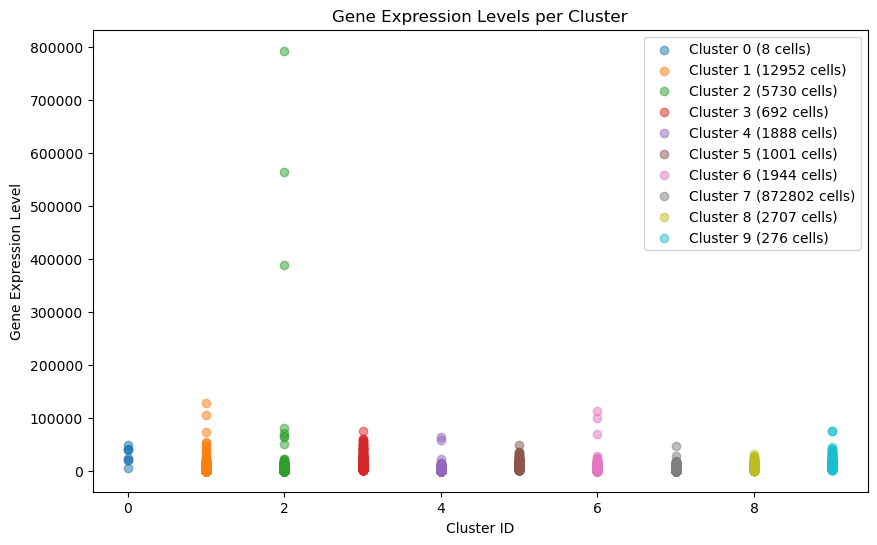

In [ ]:
labels_cpu = labels.cpu().numpy()
gene_expression_levels_cpu = gene_expression_levels


plt.figure(figsize=(10, 6))
unique_labels = np.unique(labels_cpu)

for label in unique_labels:
    cluster_cells = gene_expression_levels_cpu[labels_cpu == label]
    num_cells = len(cluster_cells)
    plt.scatter(np.full_like(cluster_cells, label), cluster_cells, alpha=0.5, label=f'Cluster {label} ({num_cells} cells)')


plt.xlabel('Cluster ID')
plt.ylabel('Gene Expression Level')
plt.title('Gene Expression Levels per Cluster')
plt.legend()
plt.show()

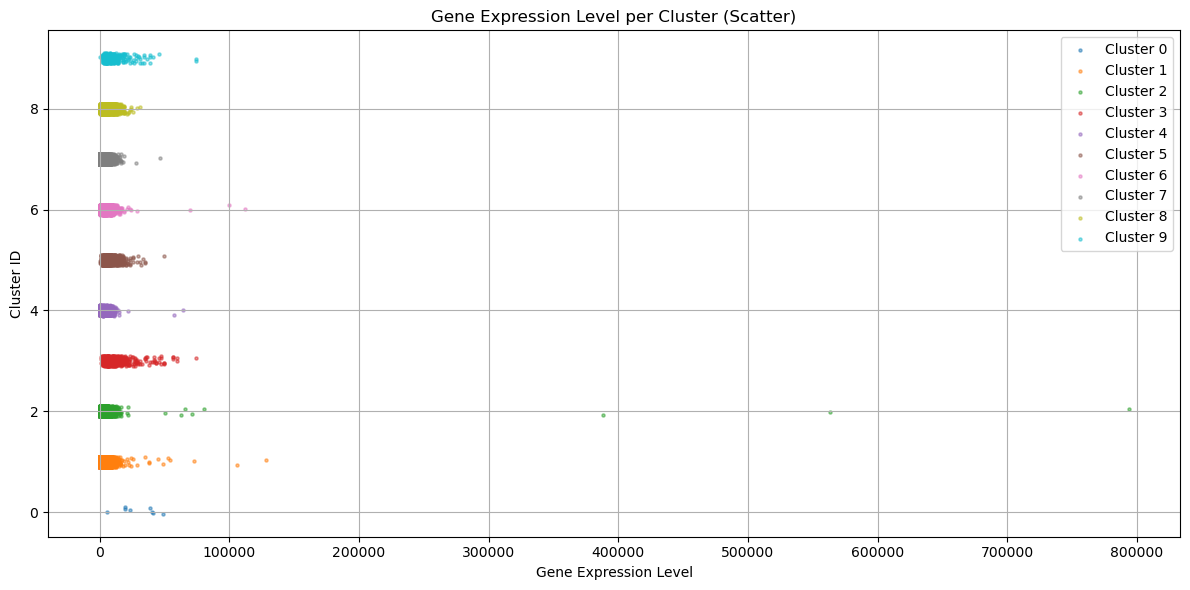

In [49]:
plt.figure(figsize=(12, 6))

for label in np.unique(labels_cpu):
    # Get gene expression values for cells in this cluster
    cluster_cells = gene_expression_levels_cpu[labels_cpu == label]
    
    # Generate random jitter for better visual separation
    y = np.full_like(cluster_cells, label) + np.random.uniform(-0.1, 0.1, size=cluster_cells.shape)

    plt.scatter(cluster_cells, y, alpha=0.5, s=5, label=f'Cluster {label}')

plt.xlabel('Gene Expression Level')
plt.ylabel('Cluster ID')
plt.title('Gene Expression Level per Cluster (Scatter)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
gc.collect()
torch.cuda.empty_cache()

Model 4 +loss function - Constrastive Loss

In [ ]:
#train with constrative-loss 
def generate_contrastive_pairs_faiss_gpu(embeddings, k=3, num_negatives=1):
    """
    Generate (i, j, y) pairs for contrastive loss using FAISS on GPU.

    Args:
        embeddings: Tensor [num_nodes, emb_dim] on GPU.
        k: # of nearest neighbors (positives).
        num_negatives: # of negative samples per node.

    Returns:
        anchor_idx, pair_idx, labels (1 for positive, 0 for negative)
    """
    device = embeddings.device
    emb_np = embeddings.detach().cpu().numpy().astype('float32')
    num_nodes = emb_np.shape[0]

    index = faiss.IndexFlatL2(emb_np.shape[1])
    if torch.cuda.is_available():
        res = faiss.StandardGpuResources()
        index = faiss.index_cpu_to_gpu(res, 0, index)
    index.add(emb_np)
    _, neighbors = index.search(emb_np, k + 1)

    anchor_idx, pair_idx, labels = [], [], []

    for i in range(num_nodes):
        # Positive pairs from neighbors (skip self)
        for j in neighbors[i][1:]:
            anchor_idx.append(i)
            pair_idx.append(j)
            labels.append(1)

        # Negative samples (not among k neighbors)
        for _ in range(num_negatives):
            j = random.randint(0, num_nodes - 1)
            while j in neighbors[i]:
                j = random.randint(0, num_nodes - 1)
            anchor_idx.append(i)
            pair_idx.append(j)
            labels.append(0)

    return (
        torch.tensor(anchor_idx, device=device),
        torch.tensor(pair_idx, device=device),
        torch.tensor(labels, dtype=torch.float32, device=device),
    )


In [ ]:
def contrastive_loss_fn(z_i, z_j, y, margin=2.0):
    """
    Contrastive loss: minimize distance for positives, maximize for negatives.
    """
    dist = F.pairwise_distance(z_i, z_j)
    loss = y * dist.pow(2) + (1 - y) * F.relu(margin - dist).pow(2)
    return loss.mean()

In [ ]:
model4 = GraphSAGE(in_channels=1, hidden_channels=8, out_channels=4, num_layers=4).to(device)

model4.train()
for epoch in range(50):  
    optimizer.zero_grad()

    embeddings = model4(data.x, data.edge_index)

    anchor_idx, pair_idx, labels = generate_contrastive_pairs_faiss_gpu(embeddings, k=5)

    z_i = embeddings[anchor_idx]
    z_j = embeddings[pair_idx]

    loss = contrastive_loss_fn(z_i, z_j, labels)
    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch+1} | Loss: {loss.item():.4f}")


Epoch 33 | Loss: 43615.1680
Epoch 34 | Loss: 98904.1953
Epoch 35 | Loss: 74163.6953
Epoch 36 | Loss: 35001.9453
Epoch 37 | Loss: 62989.0664
Epoch 38 | Loss: 38658.8320
Epoch 39 | Loss: 90497.1484
Epoch 40 | Loss: 27790.8867
Epoch 41 | Loss: 79402.7344
Epoch 42 | Loss: 47381.1406
Epoch 43 | Loss: 62542.7344
Epoch 44 | Loss: 55736.8867
Epoch 45 | Loss: 37790.8242
Epoch 46 | Loss: 71595.9531
Epoch 47 | Loss: 35817.4922
Epoch 48 | Loss: 40285.3750
Epoch 49 | Loss: 28531.5039
Epoch 50 | Loss: 35587.7852


In [ ]:
model4.eval()
with torch.no_grad():
    embeddings_model4 = model1_2(data.x, data.edge_index)

print(embeddings_model4.shape)


torch.save(model4, 'entire_model4.pth')

torch.Size([900000, 64])


In [50]:
embeddings_np = embeddings_model4.cpu().numpy()

d = embeddings_np.shape[1]  
k = 10
kmeans = faiss.Kmeans(d, k, niter=300, gpu=True)  


kmeans.train(embeddings_np)
_, labels = kmeans.index.search(embeddings_np, 1)


labels = torch.tensor(labels.flatten(), device='cuda')
print(labels.shape)

torch.Size([900000])


In [51]:
cluster_counts = torch.bincount(labels)

# Print the number of cells in each cluster
for i, count in enumerate(cluster_counts):
    print(f"Cluster {i}: {count.item()} cells")

Cluster 0: 4 cells
Cluster 1: 20584 cells
Cluster 2: 862495 cells
Cluster 3: 554 cells
Cluster 4: 6610 cells
Cluster 5: 1974 cells
Cluster 6: 361 cells
Cluster 7: 4582 cells
Cluster 8: 2349 cells
Cluster 9: 487 cells


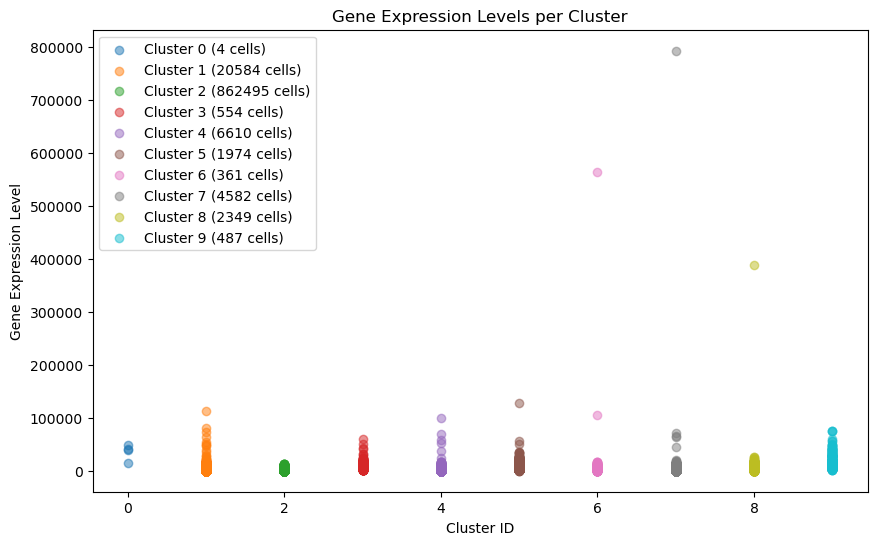

In [52]:
labels_cpu = labels.cpu().numpy()
gene_expression_levels_cpu = gene_expression_levels


plt.figure(figsize=(10, 6))
unique_labels = np.unique(labels_cpu)

for label in unique_labels:
    cluster_cells = gene_expression_levels_cpu[labels_cpu == label]
    num_cells = len(cluster_cells)
    plt.scatter(np.full_like(cluster_cells, label), cluster_cells, alpha=0.5, label=f'Cluster {label} ({num_cells} cells)')


plt.xlabel('Cluster ID')
plt.ylabel('Gene Expression Level')
plt.title('Gene Expression Levels per Cluster')
plt.legend()
plt.show()

C:\Users\shera\AppData\Local\Temp\ipykernel_6504\1076778496.py:17: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
c:\Users\shera\anaconda3\envs\scRareCellDetect\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


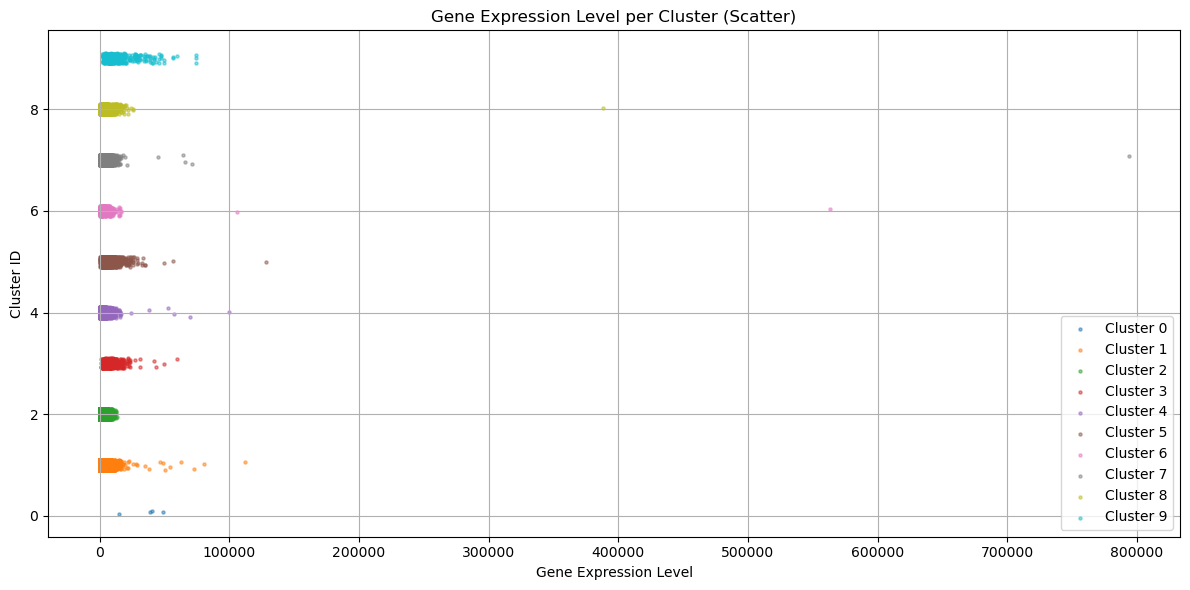

In [53]:
plt.figure(figsize=(12, 6))

for label in np.unique(labels_cpu):
    # Get gene expression values for cells in this cluster
    cluster_cells = gene_expression_levels_cpu[labels_cpu == label]
    
    # Generate random jitter for better visual separation
    y = np.full_like(cluster_cells, label) + np.random.uniform(-0.1, 0.1, size=cluster_cells.shape)

    plt.scatter(cluster_cells, y, alpha=0.5, s=5, label=f'Cluster {label}')

plt.xlabel('Gene Expression Level')
plt.ylabel('Cluster ID')
plt.title('Gene Expression Level per Cluster (Scatter)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()